# YOLOv8n Crack Detection — Edge-Optimized Compression Pipeline

## Experimental plan

| Stage | Pipelines | Purpose |
|---|---|---|
| **0** | `S0_FP32` | Reference — trained once, used for comparison only |
| **1** | `S1_FP16`, `S1_INT8`, | Post-Training Quantization (PTQ) |
| **2** | `S2_QAT_INT8` | Quantization-Aware Training |
| **3** | `S3_PrunedINT8` | One-shot 10% prune → masked fine-tune → INT8 |
| **Round 1** | All Stage 1/2/3 ranked by **PiScore** | Pick top-3 for resolution sweep |
| **4** | top-3 × {640, 512, 416, 320}px | Find best (model, resolution) for Pi |


## 1. Setup — imports, paths, device

In [ ]:



import os, sys, time, gzip, shutil, copy, json, math, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from ultralytics import YOLO

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch={torch.__version__}  device={device}  cuda={torch.cuda.is_available()}')

# -------------------- Paths (FIXED) --------------------
PROJECT_DIR  = Path('/home/samy/Niyati/edge_ai_project')

DATASET_DIR  = PROJECT_DIR / 'Crack.v2-2026-4-12_augumented.yolov8'
data_yaml    = str(DATASET_DIR / 'data.yaml')

RUNS_DIR     = PROJECT_DIR / 'runs_v3'
RUNS_DIR.mkdir(exist_ok=True)

EXPORT_DIR   = PROJECT_DIR / 'exports_v3'
EXPORT_DIR.mkdir(exist_ok=True)

STAGE4_DIR   = PROJECT_DIR / 'stage4_v3'
STAGE4_DIR.mkdir(exist_ok=True)

# -------------------- Hyperparams --------------------
BASE_EPOCHS    = 30
FT_EPOCHS      = 15
BATCH          = 16
IMGSZ_BASE     = 640
PRUNE_AMOUNT   = 0.10
SKIP_NAME      = 'model.22'

# -------------------- Verify --------------------
print(f'PROJECT_DIR = {PROJECT_DIR}')
print(f'DATASET_DIR = {DATASET_DIR}')
print(f'data_yaml   = {data_yaml}')
print(f'exists      = {Path(data_yaml).is_file()}')

torch=2.5.1+cu121  device=cuda  cuda=True
PROJECT_DIR = /home/samy/Niyati/edge_ai_project
DATASET_DIR = /home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8
data_yaml   = /home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml
exists      = True


## 2. Helper functions

- `gzip_size` — wire-size of a TFLite file
- `evaluate_tflite` — mAP@0.5 / mAP@0.5:0.95 via Ultralytics val on a TFLite model
- `bench_tflite` — CPU latency (50 warmup + 200 timed runs, 4 threads + XNNPACK)
- `attach_persistent_pruning` — keeps pruned weights at zero across fine-tuning
- `snap_to_int8_grid` — QAT callback: rounds weights to INT8 grid after every batch

In [ ]:
import tensorflow as tf

# ---------- File-size helpers ----------
def gzip_size(path):
    raw = Path(path).read_bytes()
    return len(gzip.compress(raw, compresslevel=9))

# ---------- mAP eval on a TFLite file ----------
def evaluate_tflite(tflite_path, data_yaml, imgsz=640):
    """Run Ultralytics val on a .tflite file. Returns (mAP50, mAP5095)."""
    y = YOLO(str(tflite_path), task='detect')
    m = y.val(data=data_yaml, imgsz=imgsz, batch=1, device='cpu',
              verbose=False, plots=False, save_json=False)
    return float(m.box.map50), float(m.box.map)

# ---------- CPU latency benchmark ----------
def bench_tflite(tflite_path, imgsz=640, warmup=50, runs=200,
                 num_threads=4, use_xnnpack=True):
    interp = tf.lite.Interpreter(model_path=str(tflite_path),
                                 num_threads=num_threads)
    interp.allocate_tensors()
    in_d = interp.get_input_details()[0]
    H, W = in_d['shape'][1], in_d['shape'][2]
    dtype = in_d['dtype']
    if dtype == np.uint8 or dtype == np.int8:
        x = np.random.randint(0, 255, (1, H, W, 3)).astype(dtype)
    else:
        x = np.random.rand(1, H, W, 3).astype(np.float32)
    for _ in range(warmup):
        interp.set_tensor(in_d['index'], x); interp.invoke()
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        interp.set_tensor(in_d['index'], x); interp.invoke()
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.percentile(times, 50)), float(np.percentile(times, 95))

def attach_persistent_pruning(yolo_obj, skip_name='model.22'):
    """Capture the current pruning mask, then re-zero pruned weights
    after every training batch so masked-FT preserves sparsity."""
    state = {'masks': {}}

    def capture(trainer):
        masks = {}
        for name, m in trainer.model.named_modules():
            if isinstance(m, nn.Conv2d) and skip_name not in name:
                masks[name] = (m.weight.data != 0).float().to(m.weight.device)
        state['masks'] = masks
        nz = sum(int(v.sum().item()) for v in masks.values())
        tot = sum(v.numel() for v in masks.values())
        print(f'[mask] captured {len(masks)} convs  '
              f'sparsity={(1-nz/tot)*100:.2f}%')

    def enforce(trainer):
        with torch.no_grad():
            for name, m in trainer.model.named_modules():
                if name in state['masks']:
                    m.weight.data.mul_(state['masks'][name])

    yolo_obj.add_callback('on_train_start', capture)
    yolo_obj.add_callback('on_train_batch_end', enforce)
    return state

def attach_qat_snap(yolo_obj, skip_name='model.22'):
    """After every batch, round each Conv weight to its INT8 grid
    (per-tensor symmetric). Trains the model to be quantization-friendly."""
    def snap(trainer):
        with torch.no_grad():
            for name, m in trainer.model.named_modules():
                if isinstance(m, nn.Conv2d) and skip_name not in name:
                    w = m.weight.data
                    s = w.abs().max() / 127.0 + 1e-9
                    m.weight.data = (w / s).round().clamp(-128, 127) * s
    yolo_obj.add_callback('on_train_batch_end', snap)

print('Helpers ready.')

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Helpers ready.


## 3. Stage 0 — FP32 baseline


In [3]:
FP32_RUN  = RUNS_DIR / 'S0_FP32'
FP32_CKPT = FP32_RUN / 'weights' / 'best.pt'

if FP32_CKPT.is_file():
    print(f'FP32 checkpoint exists, skipping training:\n  {FP32_CKPT}')
else:
    yolo = YOLO('yolov8n.pt')
    yolo.train(
        data=data_yaml, epochs=BASE_EPOCHS, batch=BATCH, imgsz=IMGSZ_BASE,
        device=0 if device == 'cuda' else 'cpu',
        project=str(RUNS_DIR), name='S0_FP32', exist_ok=True,
        verbose=True, plots=False,
    )
    print(f'FP32 training done: {FP32_CKPT}')

FP32 checkpoint exists, skipping training:
  /home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best.pt


In [ ]:

fp32 = YOLO(str(FP32_CKPT))
m = fp32.val(data=data_yaml, imgsz=IMGSZ_BASE, batch=1, device='cpu',
             verbose=False, plots=False, save_json=False)
fp32_map50   = float(m.box.map50)
fp32_map5095 = float(m.box.map)
fp32_size_mb = FP32_CKPT.stat().st_size / 1e6

img = np.random.randint(0, 255, (IMGSZ_BASE, IMGSZ_BASE, 3), dtype=np.uint8)
for _ in range(10):
    fp32.predict(img, imgsz=IMGSZ_BASE, device='cpu', verbose=False)
ts = []
for _ in range(50):
    t0 = time.perf_counter()
    fp32.predict(img, imgsz=IMGSZ_BASE, device='cpu', verbose=False)
    ts.append((time.perf_counter() - t0) * 1000)
fp32_p50 = float(np.percentile(ts, 50))
fp32_p95 = float(np.percentile(ts, 95))

print(f'FP32 baseline: mAP50={fp32_map50:.4f}  mAP50-95={fp32_map5095:.4f}')
print(f'              p50={fp32_p50:.2f}ms  p95={fp32_p95:.2f}ms  size={fp32_size_mb:.2f}MB')
results = {}
results['S0_FP32'] = dict(
    mAP50=fp32_map50, mAP5095=fp32_map5095,
    p50_cpu_ms=fp32_p50, p95_cpu_ms=fp32_p95,
    size_mb=fp32_size_mb,
    gzip_mb=gzip_size(FP32_CKPT) / 1e6,
)
pipelines    = {'S0_FP32': fp32}
tflite_paths = {}

Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (13th Gen Intel Core i9-13900K)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1373.8±681.5 MB/s, size: 25.9 KB)


val: Scanning /home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/valid/labels.cache... 349 images, 104 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 73.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 349/349 22.4it/s 15.6s0.1s
                   all        349        391       0.71      0.687      0.715      0.514
Speed: 0.4ms preprocess, 40.9ms inference, 0.0ms loss, 0.4ms postprocess per image
FP32 baseline: mAP50=0.7146  mAP50-95=0.5137
              p50=38.60ms  p95=44.71ms  size=6.25MB


In [5]:
def export_and_eval(yolo_obj, tag, *, fmt='tflite', int8=False, half=False,
                    imgsz=IMGSZ_BASE, extra=None):
    """Export the model, then measure size + latency + mAP.
    Stores the metrics in results[tag] and returns them."""
    print(f'\nExporting {tag} ...')
    out = yolo_obj.export(format=fmt, int8=int8, half=half,
                          data=data_yaml, imgsz=imgsz, device='cpu',
                          verbose=False)
    out = Path(out)
    if extra is not None and 'override_path' in extra:
        out = Path(extra['override_path'])
    tflite_paths[tag] = out

    map50, map5095 = evaluate_tflite(out, data_yaml, imgsz=imgsz)
    p50, p95       = bench_tflite(out, imgsz=imgsz)
    size_mb        = out.stat().st_size / 1e6
    gz_mb          = gzip_size(out) / 1e6

    results[tag] = dict(
        mAP50=map50, mAP5095=map5095,
        p50_cpu_ms=p50, p95_cpu_ms=p95,
        size_mb=size_mb, gzip_mb=gz_mb,
    )
    print(f'   mAP50={map50:.4f}  p50={p50:.2f}ms  size={size_mb:.2f}MB  file={out.name}')
    return results[tag]

In [31]:
# S1_FP16
export_and_eval(
    YOLO(str(FP32_CKPT)),
    'S1_FP16',
    fmt='tflite',
    int8=False,
    half=True
)


Exporting S1_FP16 ...
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (13th Gen Intel Core i9-13900K)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...

ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 0.5s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best.onnx' (11.8 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(s

I0000 00:00:1777555281.213809  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777555281.213901  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777555281.479307  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777555281.479323  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777555281.813135  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777555281.813240  440629 single_machine.cc:374] Starting new session


TensorFlow SavedModel: export success ✅ 5.1s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best_saved_model' (29.5 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best_saved_model/best_float16.tflite' (5.9 MB)

Export complete (5.3s)
Results saved to /home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights
Predict:         yolo predict task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best_saved_model/best_float16.tflite imgsz=640 half
Validate:        yolo val task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best_saved_model/best_float16.tflite imgsz=640 data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml half 
Visualize:       https://netron.app
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (13th Gen Intel Core i9-13900K)
Loading /home/samy/

W0000 00:00:1777555282.382385  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777555282.382403  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2444.7±1484.6 MB/s, size: 29.7 KB)
val: Scanning /home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/valid/labels.cache... 349 images, 104 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 104.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 349/349 12.6it/s 27.6s0.2ss
                   all        349        391      0.811      0.624      0.709      0.521
Speed: 0.3ms preprocess, 75.2ms inference, 0.0ms loss, 0.5ms postprocess per image
   mAP50=0.7086  p50=21.61ms  size=6.18MB  file=best_float16.tflite


{'mAP50': 0.7085511653636873,
 'mAP5095': 0.5207880269263878,
 'p50_cpu_ms': 21.610138001051382,
 'p95_cpu_ms': 30.224063400964948,
 'size_mb': 6.183523,
 'gzip_mb': 5.606613}

In [6]:
# S1_INT8
export_and_eval(YOLO(str(FP32_CKPT)), 'S1_INT8', fmt='tflite', int8=True)


Exporting S1_INT8 ...
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (13th Gen Intel Core i9-13900K)


Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 3361.3±2952.2 MB/s, size: 30.3 KB)
Scanning /home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/valid/labels.cache... 349 images, 104 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 162.6Mit/s 0.0s

ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 0.5s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best.onnx' (11.8 MB)
TensorFlow SavedModel: starting TFLite export with onnx2t

I0000 00:00:1777542932.223332  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777542932.223494  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777542932.487248  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777542932.487282  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777542932.825889  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777542932.825974  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777542933.042080  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777542933.042096  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777542933.420235  440629 devices.cc:76] Number of

W0000 00:00:1777542935.156566  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777542935.156582  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777542935.171672  440629 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1777543143.749723  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777543143.749742  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1777543349.469527  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777543349.469555  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1777543787.631461  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_for

TensorFlow SavedModel: export success ✅ 1361.3s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best_saved_model' (38.9 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best_saved_model/best_int8.tflite' (3.2 MB)

Export complete (1361.5s)
Results saved to /home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights
Predict:         yolo predict task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best_saved_model/best_int8.tflite imgsz=640 int8
Validate:        yolo val task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S0_FP32/weights/best_saved_model/best_int8.tflite imgsz=640 data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml int8 
Visualize:       https://netron.app
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (13th Gen Intel Core i9-13900K)
Loading /home/samy/Niy

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 349/349 17.5it/s 20.0s<0.0s
                   all        349        391       0.78      0.645      0.709      0.521
Speed: 1.3ms preprocess, 50.2ms inference, 0.0ms loss, 1.7ms postprocess per image
   mAP50=0.7090  p50=20.34ms  size=3.35MB  file=best_int8.tflite


{'mAP50': 0.709018450435827,
 'mAP5095': 0.5211817471682847,
 'p50_cpu_ms': 20.343582001260074,
 'p95_cpu_ms': 36.2976958008403,
 'size_mb': 3.346828,
 'gzip_mb': 2.645287}

## 5. Stage 2 — QAT INT8

Fine-tune from the FP32 checkpoint with a **snap-to-INT8-grid** callback after every batch. The model learns weights that survive INT8 quantization with less mAP loss than vanilla PTQ.

In [8]:
QAT_RUN  = RUNS_DIR / 'S2_QAT'
QAT_CKPT = QAT_RUN / 'weights' / 'best.pt'

if QAT_CKPT.is_file():
    print(f'QAT checkpoint exists, reusing:\n  {QAT_CKPT}')
    yolo_qat = YOLO(str(QAT_CKPT))
else:
    yolo_qat = YOLO(str(FP32_CKPT))
    attach_qat_snap(yolo_qat, skip_name=SKIP_NAME)
    yolo_qat.train(
        data=data_yaml, epochs=FT_EPOCHS, batch=BATCH, imgsz=IMGSZ_BASE,
        lr0=1e-4, device=0 if device == 'cuda' else 'cpu',
        project=str(RUNS_DIR), name='S2_QAT', exist_ok=True,
        verbose=True, plots=False,
    )
    yolo_qat = YOLO(str(QAT_CKPT))

pipelines['S2_QAT_INT8'] = yolo_qat
export_and_eval(yolo_qat, 'S2_QAT_INT8', fmt='tflite', int8=True)

QAT checkpoint exists, reusing:
  /home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best.pt

Exporting S2_QAT_INT8 ...
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (13th Gen Intel Core i9-13900K)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 2470.6±1068.7 MB/s, size: 27.2 KB)
Scanning /home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/valid/labels.cache... 349 images, 104 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 77.0Mit/s 0.0s

ONNX: starting export with onnx 1.21.0 opset 19...


I0000 00:00:1777544324.991884  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777544324.991988  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777544325.358943  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777544325.358973  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777544326.199233  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777544326.199343  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777544326.479389  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777544326.479412  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777544327.132528  440629 devices.cc:76] Number of

W0000 00:00:1777544329.277148  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777544329.277175  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1777544593.105102  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777544593.105124  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1777544847.330419  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777544847.330442  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1777545347.250660  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777545347.250676  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TensorFlow SavedModel: export success ✅ 1509.8s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model' (38.9 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model/best_int8.tflite' (3.2 MB)

Export complete (1510.0s)
Results saved to /home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights
Predict:         yolo predict task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model/best_int8.tflite imgsz=640 int8
Validate:        yolo val task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model/best_int8.tflite imgsz=640 data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml int8 
Visualize:       https://netron.app
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (13th Gen Intel Core i9-13900K)
Loading /home/samy/Niyati/e

{'mAP50': 0.7182636721442315,
 'mAP5095': 0.5254403233767159,
 'p50_cpu_ms': 18.327519497688627,
 'p95_cpu_ms': 25.75190175030002,
 'size_mb': 3.347428,
 'gzip_mb': 2.629478}

## 6. Stage 3 — One-shot 10% prune → masked fine-tune → INT8

1. L1-unstructured prune 10% of every Conv2d weight (skip detection head).
2. Fine-tune for 15 epochs with a callback that re-zeros the pruned weights after every batch — that's the **masked** part. Without this the optimizer pulls the zeros back to small nonzero values within a few epochs.
3. Export to INT8 TFLite.

In [ ]:
# -------------------- Stage 3: SIMPLE PRUNING (STABLE VERSION) --------------------

PRUNE_RUN  = RUNS_DIR / 'S3_Pruned'
PRUNE_CKPT = PRUNE_RUN / 'weights' / 'best.pt'

# Clean previous run
if (PRUNE_RUN / 'weights').exists():
    print('Removing old pruned weights...')
    shutil.rmtree(PRUNE_RUN / 'weights', ignore_errors=True)

# Load FP32 model
yolo_pr = YOLO(str(FP32_CKPT))

# -------------------- Apply pruning --------------------
n_pruned = 0

for name, m in yolo_pr.model.named_modules():
    if isinstance(m, nn.Conv2d) and SKIP_NAME not in name:
        prune.l1_unstructured(m, name='weight', amount=PRUNE_AMOUNT)
        prune.remove(m, 'weight')

        n_pruned += 1

# Check sparsity
z = sum(int((m.weight == 0).sum()) for n, m in yolo_pr.model.named_modules()
        if isinstance(m, nn.Conv2d) and SKIP_NAME not in n)
t = sum(m.weight.numel() for n, m in yolo_pr.model.named_modules()
        if isinstance(m, nn.Conv2d) and SKIP_NAME not in n)

print(f'Initial sparsity = {z/t*100:.2f}%')

# -------------------- Fine-tune --------------------
yolo_pr.train(
    data=data_yaml,
    epochs=FT_EPOCHS,
    batch=BATCH,
    imgsz=IMGSZ_BASE,
    lr0=1e-4,
    device=0 if device == 'cuda' else 'cpu',
    project=str(RUNS_DIR),
    name='S3_Pruned',
    exist_ok=True,
    verbose=True,
    plots=False,
)

# Reload trained model
yolo_pr = YOLO(str(PRUNE_CKPT))

# Final sparsity check
z = sum(int((m.weight == 0).sum()) for n, m in yolo_pr.model.named_modules()
        if isinstance(m, nn.Conv2d) and SKIP_NAME not in n)
t = sum(m.weight.numel() for n, m in yolo_pr.model.named_modules()
        if isinstance(m, nn.Conv2d) and SKIP_NAME not in n)

print(f'Post-FT sparsity = {z/t*100:.2f}%')

# -------------------- Register + export --------------------
pipelines['S3_PrunedINT8'] = yolo_pr

export_and_eval(
    yolo_pr,
    'S3_PrunedINT8',
    fmt='tflite',
    int8=True
)

Removing old pruned weights...
Initial sparsity = 10.00%
New https://pypi.org/project/ultralytics/8.4.45 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24068MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01,

I0000 00:00:1777563525.842272  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777563525.842342  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777563526.062656  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777563526.062671  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777563526.370613  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777563526.370705  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777563526.584880  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777563526.584896  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777563526.905927  440629 devices.cc:76] Number of

W0000 00:00:1777563528.662826  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777563528.662840  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1777563710.617826  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777563710.617841  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1777563888.742852  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777563888.742865  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1777564242.240573  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777564242.240588  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TensorFlow SavedModel: export success ✅ 1083.7s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights/best_saved_model' (38.9 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights/best_saved_model/best_int8.tflite' (3.2 MB)

Export complete (1083.8s)
Results saved to /home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights
Predict:         yolo predict task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights/best_saved_model/best_int8.tflite imgsz=640 int8
Validate:        yolo val task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights/best_saved_model/best_int8.tflite imgsz=640 data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml int8 
Visualize:       https://netron.app
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (13th Gen Intel Core i9-13900K)
Loading /hom

{'mAP50': 0.7353174359487116,
 'mAP5095': 0.5286555970435393,
 'p50_cpu_ms': 10.712983501434792,
 'p95_cpu_ms': 13.536591854062863,
 'size_mb': 3.347522,
 'gzip_mb': 2.667017}

## 7. Round 1 — comparison table + Top-3 selection


In [52]:
def build_table(results_dict, fp32_key='S0_FP32'):
    df = pd.DataFrame(results_dict).T
    fp32 = df.loc[fp32_key]
    df['mAP_drop']      = (fp32['mAP50']  - df['mAP50']).round(4)
    df['Compression_x'] = (fp32['size_mb'] / df['size_mb']).round(2)
    df['Speedup_x']     = (fp32['p50_cpu_ms'] / df['p50_cpu_ms']).round(2)
    df['BPP']           = (df['size_mb'] * 8 / (IMGSZ_BASE*IMGSZ_BASE/1e6)).round(3)
    df['FPS']           = (1000.0 / df['p50_cpu_ms']).round(2)
    df['gzip_ratio']    = (df['size_mb'] / df['gzip_mb']).round(2)
    return df.round(4)

table_r1 = build_table(results)
print('=' * 90)
print('Round 1: full table')
print('=' * 90)
print(table_r1.to_string())

Round 1: full table
                mAP50  mAP5095  p50_cpu_ms  p95_cpu_ms  size_mb  gzip_mb  mAP_drop  Compression_x  Speedup_x      BPP    FPS  gzip_ratio
S0_FP32        0.7146   0.5137     38.5955     44.7146   6.2464   5.6713    0.0000           1.00       1.00  121.999  25.91        1.10
S1_INT8        0.7090   0.5212     20.3436     36.2977   3.3468   2.6453    0.0056           1.87       1.90   65.368  49.16        1.27
S2_QAT_INT8    0.7183   0.5254     18.3275     25.7519   3.3474   2.6295   -0.0037           1.87       2.11   65.379  54.56        1.27
S3_PrunedINT8  0.7353   0.5287     10.7130     13.5366   3.3475   2.6670   -0.0207           1.87       3.60   65.381  93.34        1.26
S1_FP16        0.7086   0.5208     21.6101     30.2241   6.1835   5.6066    0.0060           1.01       1.79  120.772  46.27        1.10


In [ ]:

WEIGHTS = {
    'mAP50':       (0.40, 'higher'),
    'p50_cpu_ms':  (0.35, 'lower'),
    'size_mb':     (0.15, 'lower'),
    'mAP_drop':    (0.00, 'lower'),
}

def pi_score(df, weights=WEIGHTS):
    s = pd.Series(0.0, index=df.index)
    for col, (w, direction) in weights.items():
        v = df[col].astype(float)
        rng = (v.max() - v.min()) + 1e-9
        n = (v - v.min()) / rng if direction == 'higher' else (v.max() - v) / rng
        s = s + w * n
    return s

CANDIDATE_PREFIXES = ('S1_', 'S2_', 'S3_')
pool = table_r1[table_r1.index.str.startswith(CANDIDATE_PREFIXES)].copy()
pool['PiScore'] = pi_score(pool)
pool_sorted = pool.sort_values('PiScore', ascending=False)
TOP2 = pool_sorted.head(2).index.tolist()

print('PiScore ranking (Stage 1-3 only):')
print(pool_sorted[['mAP50', 'p50_cpu_ms', 'size_mb', 'mAP_drop', 'PiScore']].round(4))
print(f'\nTOP2= {TOP2}')

def pareto_front(df, lower=('p50_cpu_ms', 'size_mb'), higher=('mAP50',)):
    keep = []
    for i, row in df.iterrows():
        dominated = False
        for j, other in df.iterrows():
            if i == j:
                continue
            le_lo  = all(other[c] <= row[c] for c in lower)
            ge_hi  = all(other[c] >= row[c] for c in higher)
            strict = (any(other[c] < row[c] for c in lower) or
                      any(other[c] > row[c] for c in higher))
            if le_lo and ge_hi and strict:
                dominated = True
                break
        if not dominated:
            keep.append(i)
    return keep

front = pareto_front(pool)
print(f'\nPareto front:        {front}')
print(f'Top-2 in Pareto set: {[m for m in TOP2 if m in front]}')
off = [m for m in TOP2 if m not in front]
if off:
    print(f'WARNING: off Pareto front: {off}')
else:
    print('All top-2 are Pareto-optimal')

PiScore ranking (Stage 1-3 only):
                mAP50  p50_cpu_ms  size_mb  mAP_drop  PiScore
S3_PrunedINT8  0.7353     10.7130   3.3475   -0.0207   0.9000
S2_QAT_INT8    0.7183     18.3275   3.3474   -0.0037   0.4007
S1_INT8        0.7090     20.3436   3.3468    0.0056   0.1967
S1_FP16        0.7086     21.6101   6.1835    0.0060   0.0000

TOP2= ['S3_PrunedINT8', 'S2_QAT_INT8']

Pareto front:        ['S1_INT8', 'S2_QAT_INT8', 'S3_PrunedINT8']
Top-2 in Pareto set: ['S3_PrunedINT8', 'S2_QAT_INT8']
All top-2 are Pareto-optimal


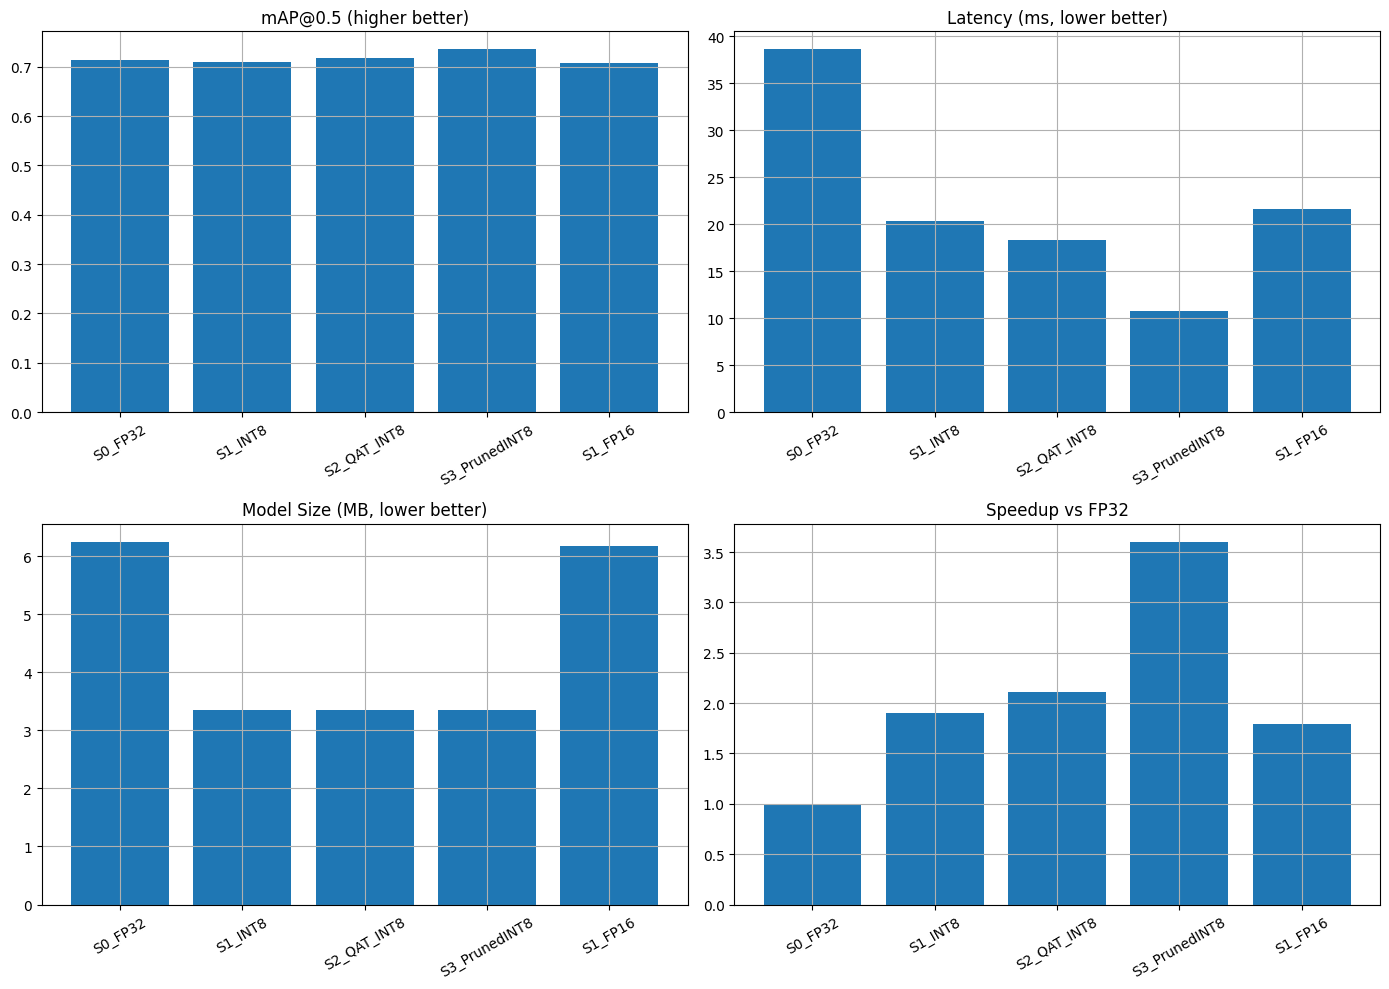

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

base_df = table_r1.copy()

df = base_df.reset_index()
df.rename(columns={'index': 'pipeline'}, inplace=True)

labels = df['pipeline']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ('mAP50', 'mAP@0.5 (higher better)'),
    ('p50_cpu_ms', 'Latency (ms, lower better)'),
    ('size_mb', 'Model Size (MB, lower better)'),
    ('Speedup_x', 'Speedup vs FP32'),
]

for ax, (col, title) in zip(axes.flat, metrics):
    ax.bar(labels, df[col])
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True)

plt.tight_layout()
plt.show()

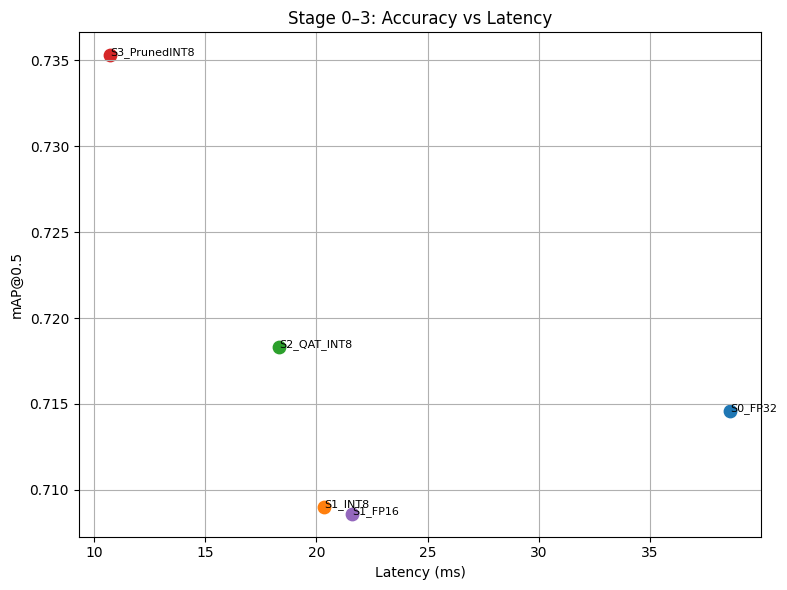

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

for idx, row in table_r1.iterrows():
    ax.scatter(row['p50_cpu_ms'], row['mAP50'], s=80)
    ax.annotate(idx, (row['p50_cpu_ms'], row['mAP50']), fontsize=8)

ax.set_xlabel('Latency (ms)')
ax.set_ylabel('mAP@0.5')
ax.set_title('Stage 0–3: Accuracy vs Latency')
ax.grid(True)

plt.tight_layout()
plt.show()

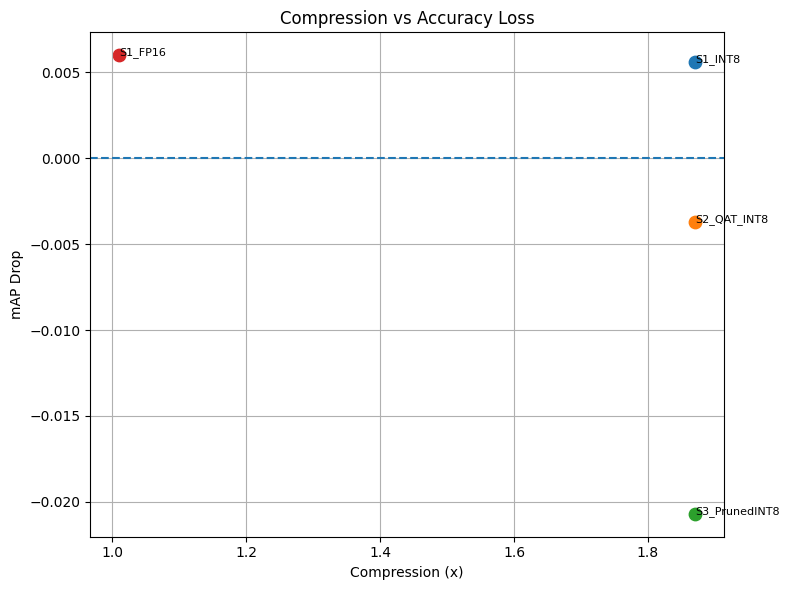

In [61]:
fig, ax = plt.subplots(figsize=(8,6))

for idx, row in table_r1.iterrows():
    if idx == 'S0_FP32':
        continue
        
    ax.scatter(row['Compression_x'], row['mAP_drop'], s=80)
    ax.annotate(idx, (row['Compression_x'], row['mAP_drop']), fontsize=8)

ax.axhline(0, linestyle='--')
ax.set_xlabel('Compression (x)')
ax.set_ylabel('mAP Drop')
ax.set_title('Compression vs Accuracy Loss')
ax.grid(True)

plt.tight_layout()
plt.show()

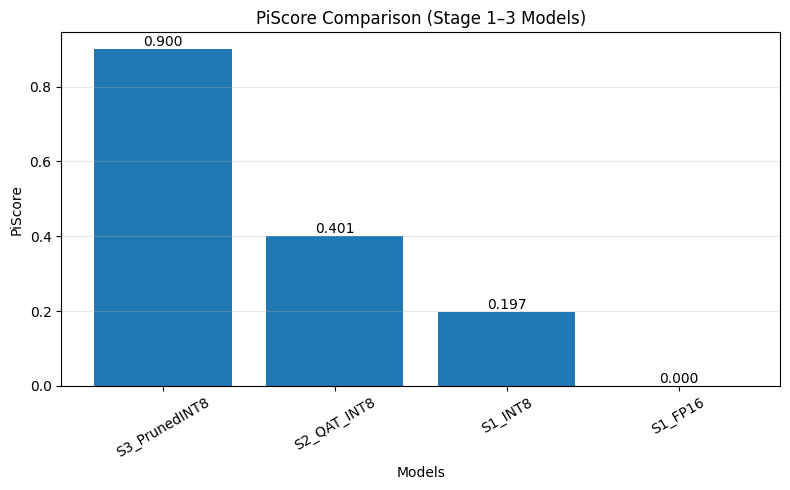

In [ ]:
import matplotlib.pyplot as plt

CANDIDATE_PREFIXES = ('S1_', 'S2_', 'S3_')
pool = table_r1[table_r1.index.str.startswith(CANDIDATE_PREFIXES)].copy()

pool['PiScore'] = pi_score(pool)
pool_sorted = pool.sort_values('PiScore', ascending=False)
plt.figure(figsize=(8,5))
bars = plt.bar(pool_sorted.index, pool_sorted['PiScore'])
for bar, val in zip(bars, pool_sorted['PiScore']):
    plt.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}',
             ha='center', va='bottom')

plt.title('PiScore Comparison (Stage 1–3 Models)')
plt.xlabel('Models')
plt.ylabel('PiScore')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Stage 4 — resolution sweep on the top-3


In [64]:
# -------------------- Stage 4: Export TOP2 (from existing TOP3) --------------------

RESOLUTIONS = [512, 416, 320]

# ✅ Use already computed TOP3 (DO NOT recompute PiScore)
if 'TOP3' not in globals():
    raise RuntimeError("TOP3 not found. Run Stage 1–3 PiScore cell first.")

print(f'Using TOP2 from TOP3: {TOP2}')

# -------------------- Map pipelines --------------------
tag_to_yolo = {
    'S1_FP16':       YOLO(str(FP32_CKPT)),
    'S1_INT8':       YOLO(str(FP32_CKPT)),
    'S2_QAT_INT8':   pipelines.get('S2_QAT_INT8'),
    'S3_PrunedINT8': pipelines.get('S3_PrunedINT8'),
}

tag_to_export_kwargs = {
    'S1_FP16':       dict(int8=False, half=True),
    'S1_INT8':       dict(int8=True,  half=False),
    'S2_QAT_INT8':   dict(int8=True,  half=False),
    'S3_PrunedINT8': dict(int8=True,  half=False),
}

stage4_paths = {}

# -------------------- Export models --------------------
for tag in TOP2:
    print(f'\n=== {tag} ===')

    yolo_obj = tag_to_yolo[tag]

    if yolo_obj is None:
        raise ValueError(f'Model for {tag} not found in pipelines.')

    for imgsz in RESOLUTIONS:
        kw = tag_to_export_kwargs[tag]

        res = yolo_obj.export(
            format='tflite',
            data=data_yaml,
            imgsz=imgsz,
            device='cpu',
            verbose=False,
            **kw
        )

        path = STAGE4_DIR / f'{tag}_r{imgsz}.tflite'
        shutil.copy(res, path)

        stage4_paths[(tag, imgsz)] = path

        print(f'  {tag} @ {imgsz}px done: {path.name} ({path.stat().st_size/1e6:.2f} MB)')

print(f'\nExported {len(stage4_paths)} files (top-2 x {len(RESOLUTIONS)} resolutions)')
print('640 px rows for the top-2 are taken from Round 1.')

Using TOP2 from TOP3: ['S3_PrunedINT8', 'S2_QAT_INT8']

=== S3_PrunedINT8 ===
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (13th Gen Intel Core i9-13900K)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 5, 5376) (6.0 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 1602.8±1054.5 MB/s, size: 15.9 KB)
Scanning /home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/valid/labels.cache... 349 images, 104 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 104.6Mit/s 0.0s

ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: slimming with onnxslim 0.1.91...
ONNX:

I0000 00:00:1777567737.394143  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777567737.394247  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777567738.017539  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777567738.017555  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777567738.329114  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777567738.329215  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777567738.540937  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777567738.540952  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777567738.852385  440629 devices.cc:76] Number of

W0000 00:00:1777567740.353556  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777567740.353569  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1777567856.494044  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777567856.494058  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1777567973.967504  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777567973.967518  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1777568207.927345  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777568207.927360  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TensorFlow SavedModel: export success ✅ 720.8s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights/best_saved_model' (38.6 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights/best_saved_model/best_int8.tflite' (3.1 MB)

Export complete (720.9s)
Results saved to /home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights
Predict:         yolo predict task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights/best_saved_model/best_int8.tflite imgsz=512 int8
Validate:        yolo val task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S3_Pruned/weights/best_saved_model/best_int8.tflite imgsz=512 data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml int8 
Visualize:       https://netron.app
  S3_PrunedINT8 @ 512px done: S3_PrunedINT8_r512.tflite (3.27 MB)
Ultralytics 8.4.39 🚀 Python-3.10.20 to

I0000 00:00:1777568452.161069  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777568452.161160  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777568452.391122  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777568452.391137  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777568452.683292  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777568452.683368  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777568452.888499  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777568452.888514  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777568453.195766  440629 devices.cc:76] Number of

...

W0000 00:00:1777570031.993495  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777570031.993515  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1777570116.223191  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777570116.223216  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1777570199.986810  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777570199.986825  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1777570366.458482  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777570366.458496  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TensorFlow SavedModel: export success ✅ 509.5s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model' (38.5 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model/best_int8.tflite' (3.1 MB)

Export complete (509.6s)
Results saved to /home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights
Predict:         yolo predict task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model/best_int8.tflite imgsz=416 int8
Validate:        yolo val task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model/best_int8.tflite imgsz=416 data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml int8 
Visualize:       https://netron.app
  S2_QAT_INT8 @ 416px done: S2_QAT_INT8_r416.tflite (3.23 MB)
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU

I0000 00:00:1777570537.606126  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777570537.606294  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777570537.977081  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777570537.977105  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777570538.320824  440629 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777570538.320905  440629 single_machine.cc:374] Starting new session
W0000 00:00:1777570538.537768  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777570538.537783  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777570538.866684  440629 devices.cc:76] Number of

W0000 00:00:1777570540.233315  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777570540.233330  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1777570591.795510  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777570591.795528  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1777570642.914986  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777570642.915004  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1777570745.456394  440629 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777570745.456411  440629 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TensorFlow SavedModel: export success ✅ 315.1s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model' (38.3 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model/best_int8.tflite' (3.0 MB)

Export complete (315.2s)
Results saved to /home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights
Predict:         yolo predict task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model/best_int8.tflite imgsz=320 int8
Validate:        yolo val task=detect model=/home/samy/Niyati/edge_ai_project/runs_v3/S2_QAT/weights/best_saved_model/best_int8.tflite imgsz=320 data=/home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/data.yaml int8 
Visualize:       https://netron.app
  S2_QAT_INT8 @ 320px done: S2_QAT_INT8_r320.tflite (3.20 MB)

Exported 6 files (top-2 x 3 resolutions)
640 px rows for

In [65]:
# Evaluate every (tag, imgsz): mAP + latency
stage4_rows = []
for (tag, imgsz), path in stage4_paths.items():
    print(f'Evaluating {tag} @ {imgsz}px ...')
    map50, map5095 = evaluate_tflite(path, data_yaml, imgsz=imgsz)
    p50, p95       = bench_tflite(path, imgsz=imgsz)
    size_mb = path.stat().st_size / 1e6
    gz_mb   = gzip_size(path) / 1e6
    stage4_rows.append({
        'pipeline':      tag,
        'imgsz':         imgsz,
        'mAP50':         round(map50, 4),
        'mAP5095':       round(map5095, 4),
        'mAP_drop':      round(fp32_map50 - map50, 4),
        'p50_cpu_ms':    round(p50, 2),
        'p95_cpu_ms':    round(p95, 2),
        'size_mb':       round(size_mb, 3),
        'gzip_mb':       round(gz_mb, 3),
        'BPP':           round(size_mb * 8 / (imgsz * imgsz / 1e6), 3),
        'FPS':           round(1000.0 / p50, 2),
        'Compression_x': round(fp32_size_mb / size_mb, 2),
        'Speedup_x':     round(fp32_p50 / p50, 2),
    })
    print(f'   mAP50={map50:.4f}  p50={p50:.2f}ms  size={size_mb:.2f}MB')

stage4_df = pd.DataFrame(stage4_rows).set_index(['pipeline', 'imgsz']).sort_index()
print('\nStage 4 results:')
print(stage4_df.round(3))

Evaluating S3_PrunedINT8 @ 512px ...
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (13th Gen Intel Core i9-13900K)
Loading /home/samy/Niyati/edge_ai_project/stage4_v3/S3_PrunedINT8_r512.tflite for TensorFlow Lite inference...
Setting batch=1 input of shape (1, 3, 512, 512)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1645.4±552.6 MB/s, size: 23.8 KB)
val: Scanning /home/samy/Niyati/edge_ai_project/Crack.v2-2026-4-12_augumented.yolov8/valid/labels.cache... 349 images, 104 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 122.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 349/349 43.2it/s 8.1s<0.0s
                   all        349        391      0.808       0.65      0.723      0.537
Speed: 0.2ms preprocess, 20.5ms inference, 0.0ms loss, 0.5ms postprocess per image
   mAP50=0.7225  p50=7.42ms  size=3.27MB
Evaluating S3_PrunedINT8 @ 416px ...
Ultralytics 8.4.39 🚀 Python-3.10.20 torch-2.5.1+cu121 CP

## 9. Final unified table — every pipeline × every resolution

In [66]:
# Promote table_r1 to MultiIndex (pipeline, imgsz=640)
r1 = table_r1.copy()
r1['pipeline'] = r1.index
r1['imgsz']    = IMGSZ_BASE
r1 = r1.set_index(['pipeline', 'imgsz'])

final_table = pd.concat([r1, stage4_df], axis=0)

# Recompute derived columns uniformly
final_table['Compression_x'] = (fp32_size_mb / final_table['size_mb']).round(2)
final_table['Speedup_x']     = (fp32_p50     / final_table['p50_cpu_ms']).round(2)
final_table['FPS']           = (1000.0       / final_table['p50_cpu_ms']).round(2)

# PiScore on the full final table (excluding the FP32 baseline row)
score_pool = final_table.drop(index=('S0_FP32', IMGSZ_BASE), errors='ignore')
final_table['PiScore'] = np.nan
final_table.loc[score_pool.index, 'PiScore'] = pi_score(
    score_pool[['mAP50', 'p50_cpu_ms', 'size_mb', 'mAP_drop']]
).values

final_table = final_table.sort_values('PiScore', ascending=False, na_position='last')

print('=' * 100)
print(f'FINAL TABLE: {len(final_table)} rows, ranked by PiScore')
print('=' * 100)
print(final_table.round(4).to_string())

FINAL TABLE: 11 rows, ranked by PiScore
                      mAP50  mAP5095  p50_cpu_ms  p95_cpu_ms  size_mb  gzip_mb  mAP_drop  Compression_x  Speedup_x      BPP     FPS  gzip_ratio  PiScore
pipeline      imgsz                                                                                                                                     
S2_QAT_INT8   416    0.7114   0.5258      4.9300      6.2800   3.2310   2.6290    0.0032           1.93       7.83  149.367  202.84         NaN   0.7668
S3_PrunedINT8 512    0.7225   0.5372      7.4200      9.5200   3.2750   2.6660   -0.0079           1.91       5.20   99.943  134.77         NaN   0.7665
              640    0.7353   0.5287     10.7130     13.5366   3.3475   2.6670   -0.0207           1.87       3.60   65.381   93.34        1.26   0.7567
S2_QAT_INT8   512    0.7215   0.5345      9.2900     10.1500   3.2750   2.6290   -0.0069           1.91       4.15   99.943  107.64         NaN   0.7251
S3_PrunedINT8 416    0.7010   0.5080      

## 10. Visualizations

### A. Pareto plot — mAP vs latency, marker size ∝ file size

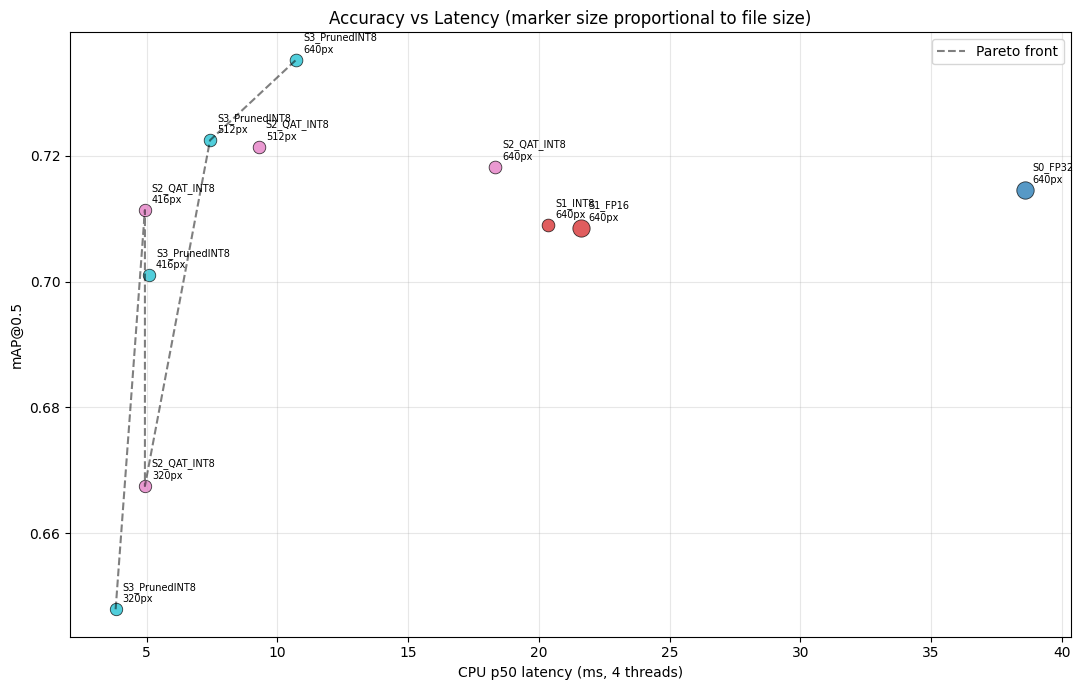

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 7))

stages = sorted({p.split('_')[0] for (p, _) in final_table.index})
colors = plt.cm.tab10(np.linspace(0, 1, len(stages)))
stage_color = dict(zip(stages, colors))

for (pipe, imgsz), row in final_table.iterrows():
    c = stage_color[pipe.split('_')[0]]
    s = max(40, row['size_mb'] * 25)
    
    ax.scatter(row['p50_cpu_ms'], row['mAP50'], s=s, c=[c],
               alpha=0.75, edgecolors='black', linewidths=0.6)
    
    ax.annotate(f'{pipe}\n{imgsz}px',
                (row['p50_cpu_ms'], row['mAP50']),
                fontsize=7,
                xytext=(5, 5),
                textcoords='offset points')

front_idx = pareto_front(final_table.reset_index().set_index(['pipeline', 'imgsz']))
front_pts = final_table.loc[front_idx].sort_values('p50_cpu_ms')

ax.plot(front_pts['p50_cpu_ms'], front_pts['mAP50'],
        'k--', alpha=0.5, label='Pareto front')

ax.set_xlabel('CPU p50 latency (ms, 4 threads)')
ax.set_ylabel('mAP@0.5')
ax.set_title('Accuracy vs Latency (marker size proportional to file size)')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### B. Resolution-sweep curves for the top-3

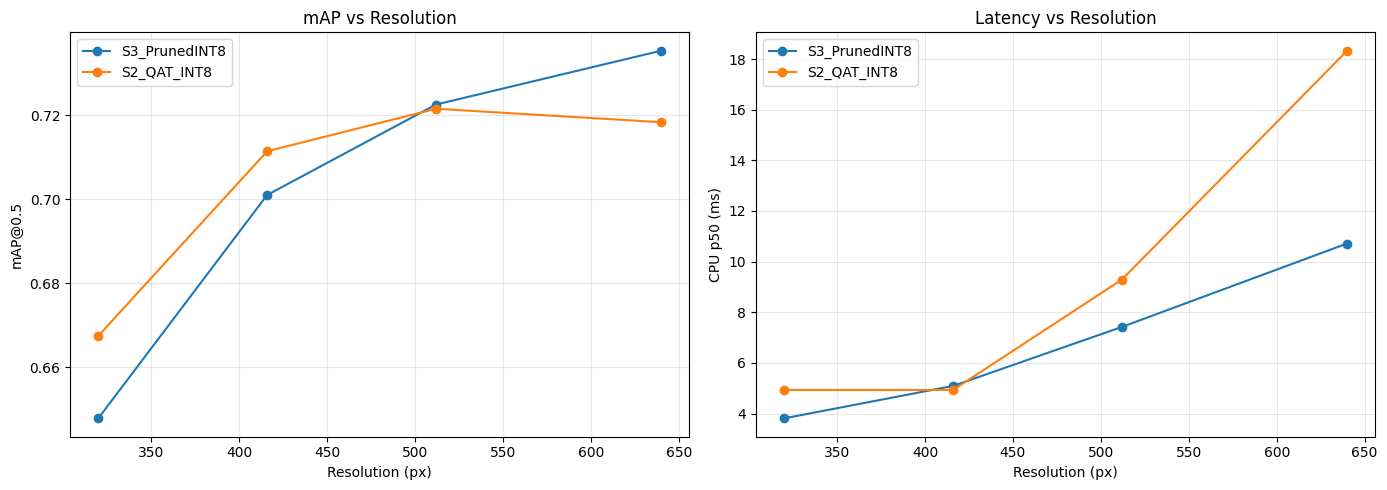

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tag in TOP2:
    s4 = stage4_df.loc[tag].sort_index()

    r1_row = table_r1.loc[tag]

    full = pd.concat([
        s4,
        pd.DataFrame({
            'mAP50':      [r1_row['mAP50']],
            'p50_cpu_ms': [r1_row['p50_cpu_ms']],
        }, index=pd.Index([IMGSZ_BASE], name='imgsz'))
    ]).sort_index()

    axes[0].plot(full.index, full['mAP50'], '-o', label=tag)
    axes[1].plot(full.index, full['p50_cpu_ms'], '-o', label=tag)


axes[0].set_xlabel('Resolution (px)')
axes[0].set_ylabel('mAP@0.5')
axes[0].set_title('mAP vs Resolution')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('Resolution (px)')
axes[1].set_ylabel('CPU p50 (ms)')
axes[1].set_title('Latency vs Resolution')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### C. Bar charts for the top-N final picks

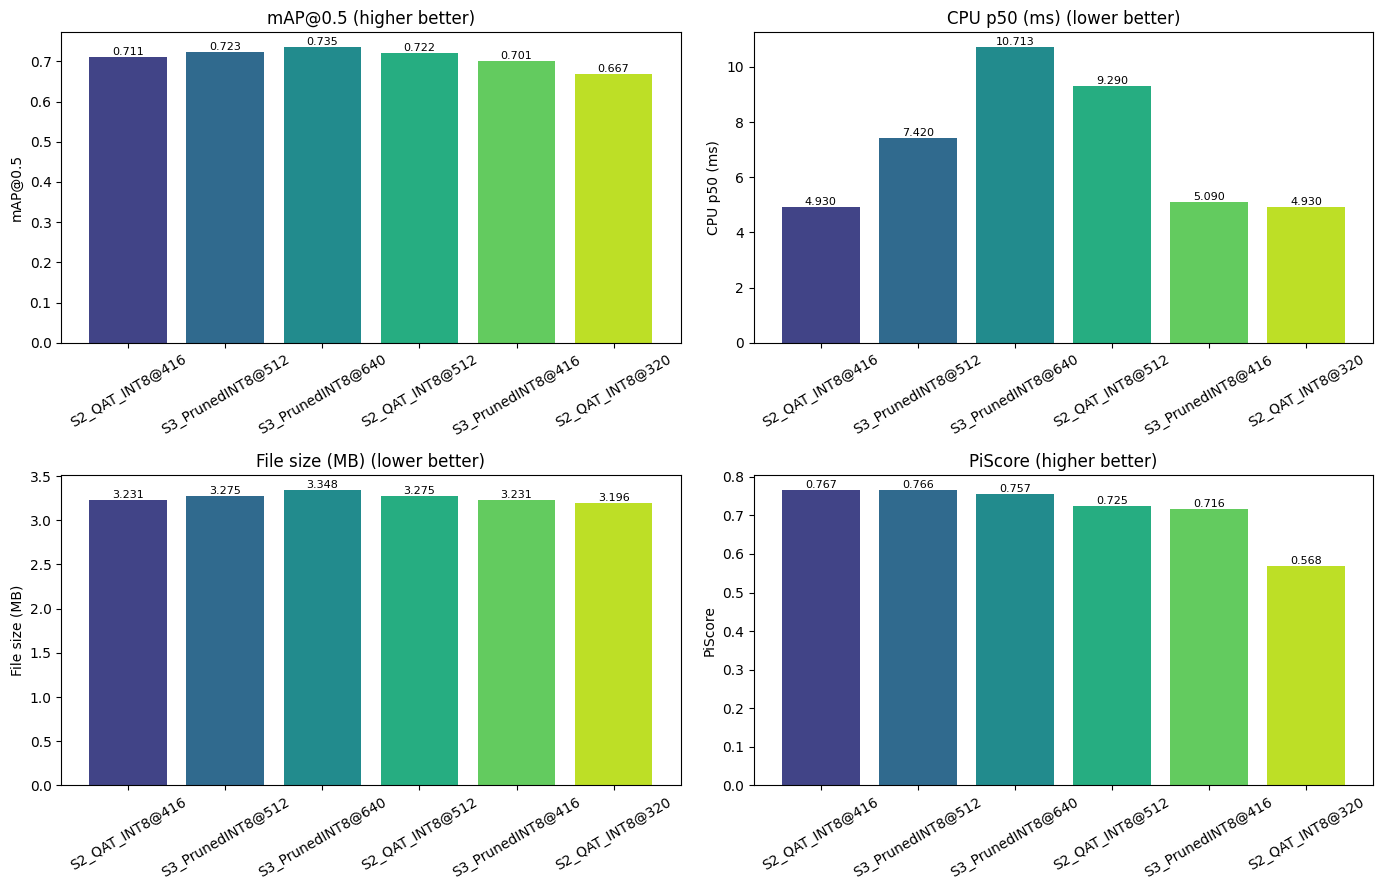

In [69]:
import matplotlib.pyplot as plt

TOP_N_FINAL = 6
top_final = final_table.dropna(subset=['PiScore']).head(TOP_N_FINAL).reset_index()
top_final['label'] = top_final['pipeline'] + '@' + top_final['imgsz'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics = [
    ('mAP50',      'mAP@0.5',        'higher'),
    ('p50_cpu_ms', 'CPU p50 (ms)',   'lower'),
    ('size_mb',    'File size (MB)', 'lower'),
    ('PiScore',    'PiScore',        'higher'),
]

for ax, (col, ylabel, direction) in zip(axes.flat, metrics):
    bars = ax.bar(top_final['label'], top_final[col],
                  color=plt.cm.viridis(np.linspace(0.2, 0.9, len(top_final))))
    
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} ({direction} better)')
    ax.tick_params(axis='x', rotation=30)
    
    for b, v in zip(bars, top_final[col]):
        ax.text(b.get_x() + b.get_width()/2, v,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### D. Compression vs accuracy trade-off

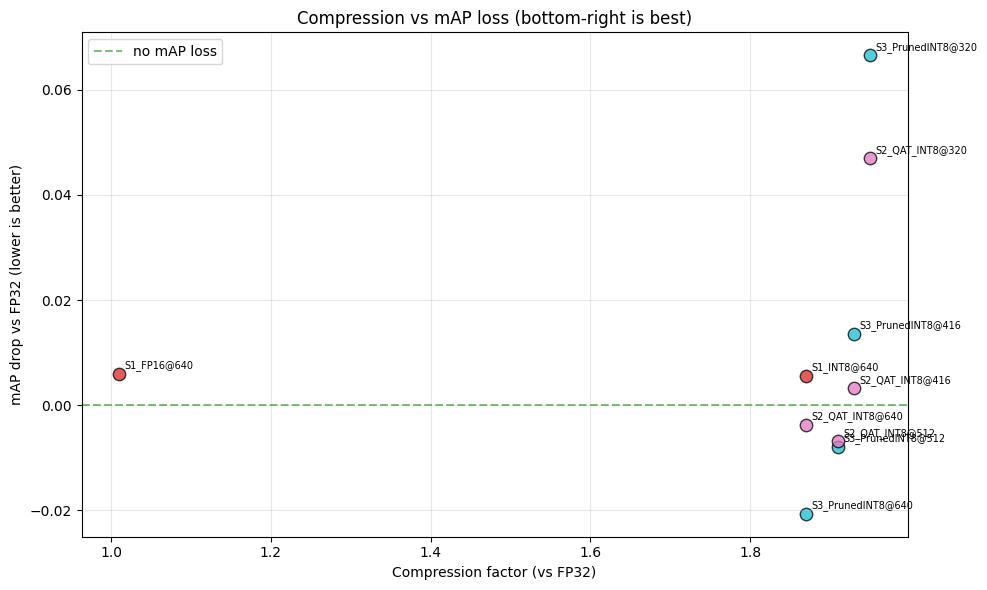

In [70]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for (pipe, imgsz), row in final_table.iterrows():
    if pipe == 'S0_FP32':
        continue

    c = stage_color[pipe.split('_')[0]]

    ax.scatter(row['Compression_x'], row['mAP_drop'],
               s=80, c=[c], edgecolors='black', alpha=0.75)

    ax.annotate(f'{pipe}@{imgsz}',
                (row['Compression_x'], row['mAP_drop']),
                fontsize=7, xytext=(4, 4),
                textcoords='offset points')

ax.axhline(0, color='green', linestyle='--', alpha=0.5,
           label='no mAP loss')

ax.set_xlabel('Compression factor (vs FP32)')
ax.set_ylabel('mAP drop vs FP32 (lower is better)')
ax.set_title('Compression vs mAP loss (bottom-right is best)')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 11. Final winner

In [71]:
winner_idx = final_table.dropna(subset=['PiScore']).index[0]
winner     = final_table.loc[winner_idx]
fp32_row   = final_table.loc[('S0_FP32', IMGSZ_BASE)]

print('=' * 70)
print(f'WINNER: {winner_idx[0]}  @  {winner_idx[1]} px')
print('=' * 70)
print(f'  mAP@0.5    : {winner["mAP50"]:.4f}   '
      f'(FP32 {fp32_row["mAP50"]:.4f}, drop {winner["mAP_drop"]:.4f})')
print(f'  CPU p50    : {winner["p50_cpu_ms"]:.2f} ms   '
      f'(FP32 {fp32_row["p50_cpu_ms"]:.2f} ms, '
      f'{winner["Speedup_x"]:.2f}x faster)')
print(f'  File size  : {winner["size_mb"]:.2f} MB    '
      f'({winner["Compression_x"]:.2f}x smaller)')
print(f'  Throughput : {winner["FPS"]:.1f} FPS @ 4-thread CPU')
print(f'  PiScore    : {winner["PiScore"]:.4f}')

winner_path = stage4_paths.get((winner_idx[0], winner_idx[1])) or \
              tflite_paths.get(winner_idx[0])
print(f'\nDeployment artifact: {winner_path}')

WINNER: S2_QAT_INT8  @  416 px
  mAP@0.5    : 0.7114   (FP32 0.7146, drop 0.0032)
  CPU p50    : 4.93 ms   (FP32 38.60 ms, 7.83x faster)
  File size  : 3.23 MB    (1.93x smaller)
  Throughput : 202.8 FPS @ 4-thread CPU
  PiScore    : 0.7668

Deployment artifact: /home/samy/Niyati/edge_ai_project/stage4_v3/S2_QAT_INT8_r416.tflite
